## Plot function for "Isolate Label Skew Effects"

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

BETA_L_VALUES = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0,50.0]
BETA_Q_VALUES = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 50.0]


def plot_macro_f1_vs_beta_L(csv_path, save_dir=None):

    df = pd.read_csv(csv_path)

    f1_cols = [
        "F1_global_AlveolarOsteitis",
        "F1_global_SecondaryInfection",
        "F1_global_NerveDysesthesia",
        "F1_global_Bleeding",
    ]

    # macro F1
    df["macro_f1"] = df[f1_cols].mean(axis=1)

    paradigms = df["paradigm"].unique()

    for beta_q in BETA_Q_VALUES:

        sub_df = df[df["beta_Q"] == beta_q].copy()

        if sub_df.empty:
            print(f"No data for beta_Q={beta_q}")
            continue

        plt.figure(figsize=(8,5))

        for paradigm in paradigms:

            p_df = sub_df[sub_df["paradigm"] == paradigm]

            # ensure correct order
            p_df = p_df.sort_values("beta_L")

            plt.plot(
                p_df["beta_L"],
                p_df["macro_f1"],
                marker="o",
                label=paradigm
            )

        plt.xlabel(r"Label skew $\beta_L$")
        plt.ylabel("Macro F1")
        plt.title(f"Macro F1 vs $\\beta_L$  (β_Q={beta_q})")

        plt.xticks(BETA_L_VALUES)

        plt.legend(title="Paradigm")
        plt.grid(True)
        plt.tight_layout()

        if save_dir is not None:
            path = f"{save_dir}/macroF1_betaQ_{beta_q}.png"
            plt.savefig(path, dpi=300, bbox_inches="tight")

        plt.show()

We Run the function on the desired dataset:

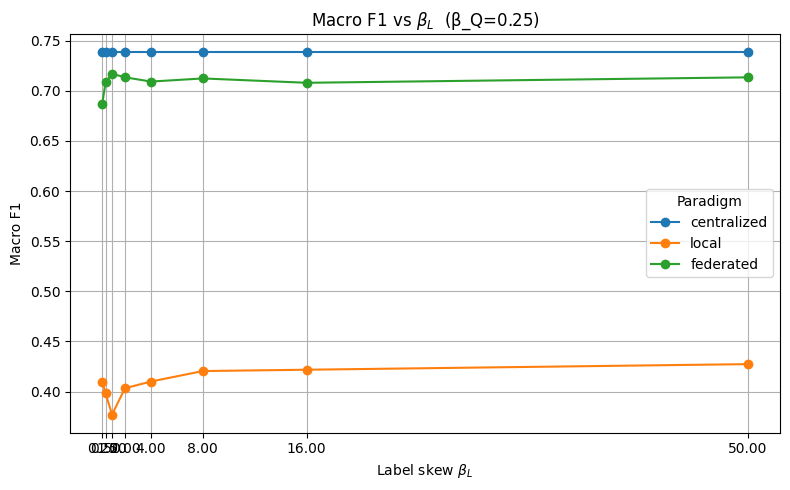

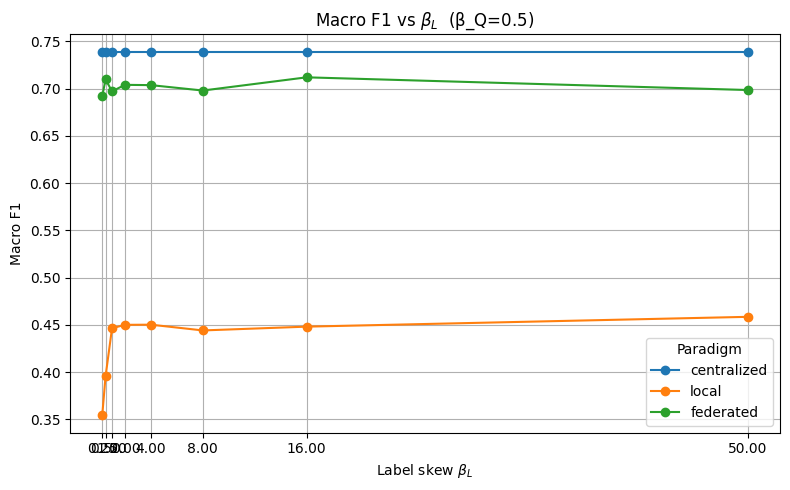

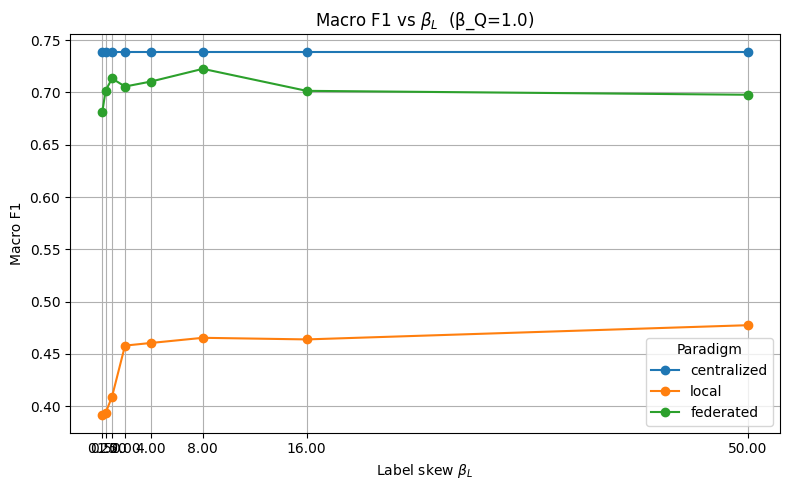

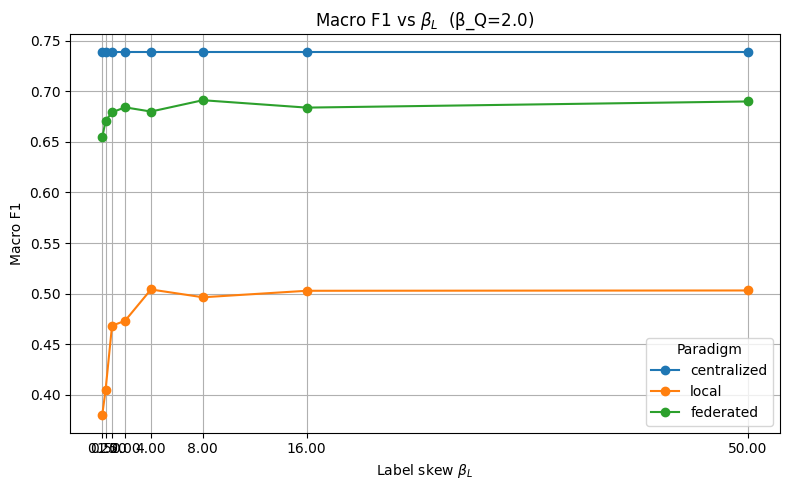

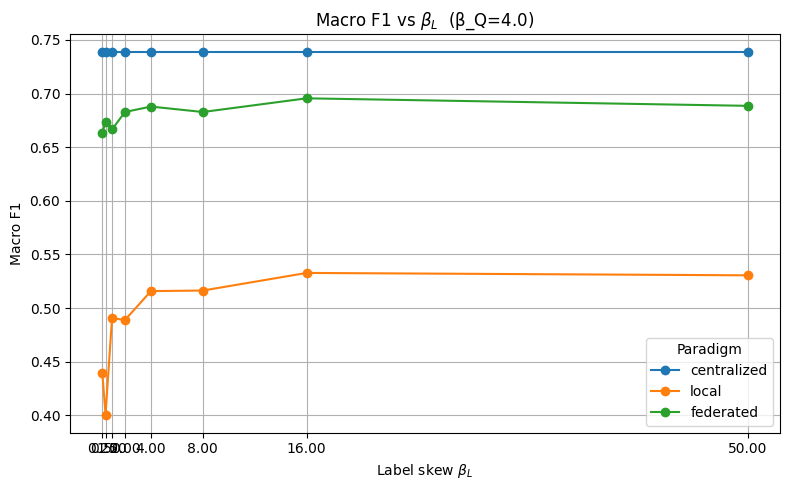

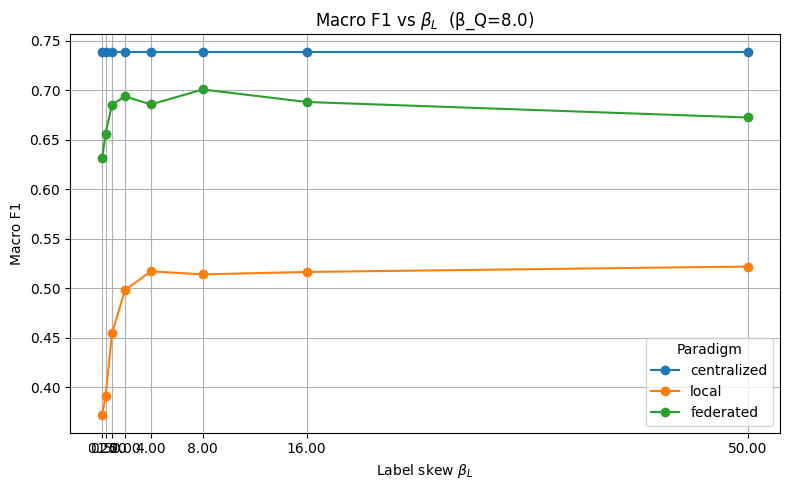

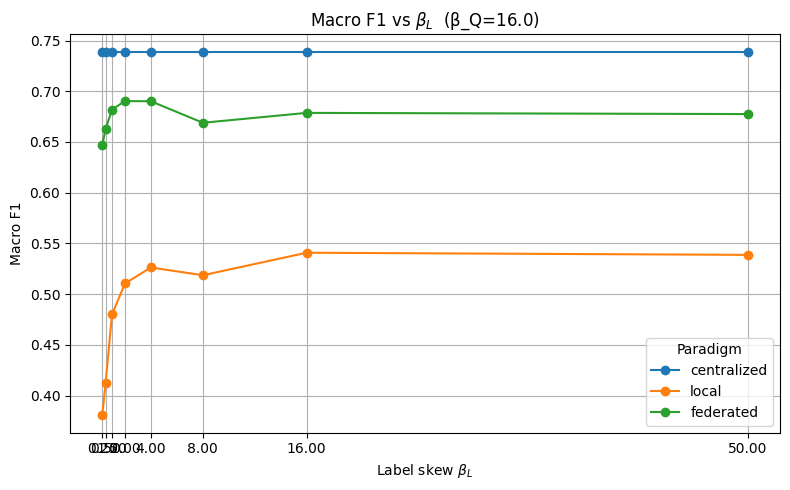

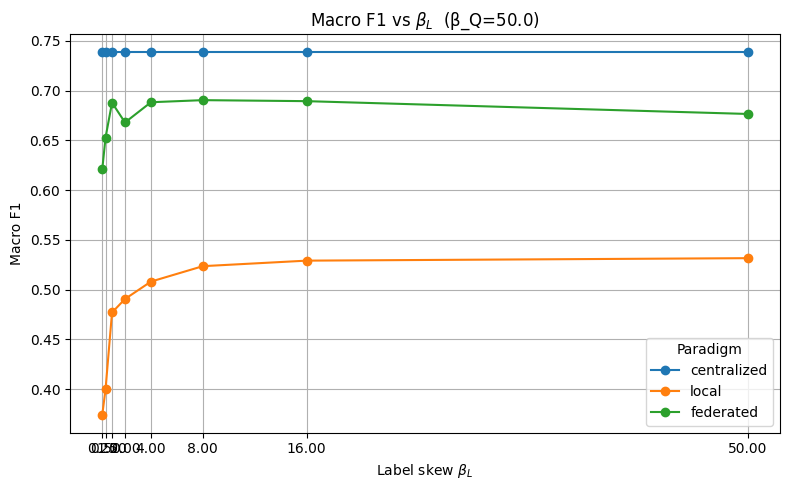

In [2]:
csv_path = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\src\fdrp\analysis\Data\sweep_beta_summary_heads_128_64.csv"
plot_macro_f1_vs_beta_L(csv_path)

We see that high label skew means low performance. Likewise we see that high quantity skew means high performance.

## Plot Function for Quantity skew

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


BETA_L_VALUES = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0,50.0]
BETA_Q_VALUES = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 50.0]


def plot_quantity_skew_all_beta_L(csv_path, save_dir=None):

    df = pd.read_csv(csv_path)

    f1_cols = [
        "F1_global_AlveolarOsteitis",
        "F1_global_SecondaryInfection",
        "F1_global_NerveDysesthesia",
        "F1_global_Bleeding",
    ]

    # compute macro F1
    df["macro_f1"] = df[f1_cols].mean(axis=1)

    paradigms = df["paradigm"].unique()

    for beta_l in BETA_L_VALUES:

        sub_df = df[df["beta_L"] == beta_l].copy()

        if sub_df.empty:
            print(f"No data for beta_L={beta_l}")
            continue

        plt.figure(figsize=(8,5))

        for paradigm in paradigms:

            p_df = sub_df[sub_df["paradigm"] == paradigm]

            p_df = p_df.sort_values("beta_Q")

            plt.plot(
                p_df["beta_Q"],
                p_df["macro_f1"],
                marker="o",
                label=paradigm
            )

        plt.xlabel(r"Quantity skew $\beta_Q$")
        plt.ylabel("Macro F1")
        plt.title(f"Macro F1 vs $\\beta_Q$  (β_L={beta_l})")

        plt.xticks(BETA_Q_VALUES)

        plt.legend(title="Paradigm")
        plt.grid(True)
        plt.tight_layout()

        if save_dir is not None:
            path = f"{save_dir}/macroF1_betaL_{beta_l}.png"
            plt.savefig(path, dpi=300, bbox_inches="tight")

        plt.show()

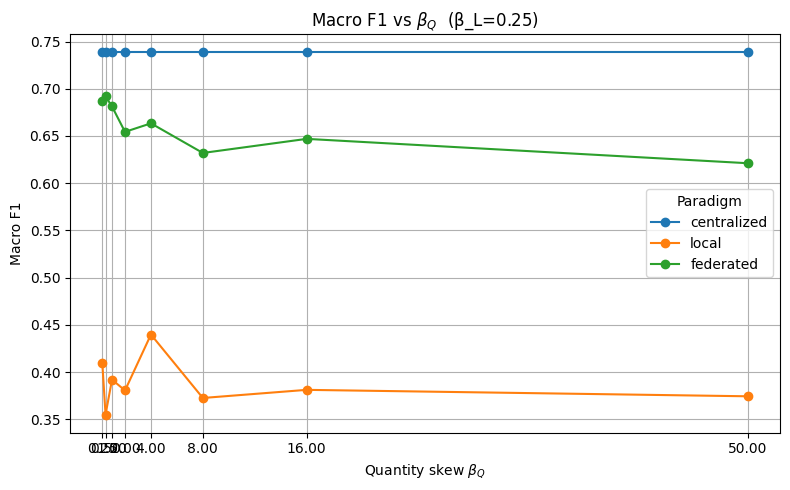

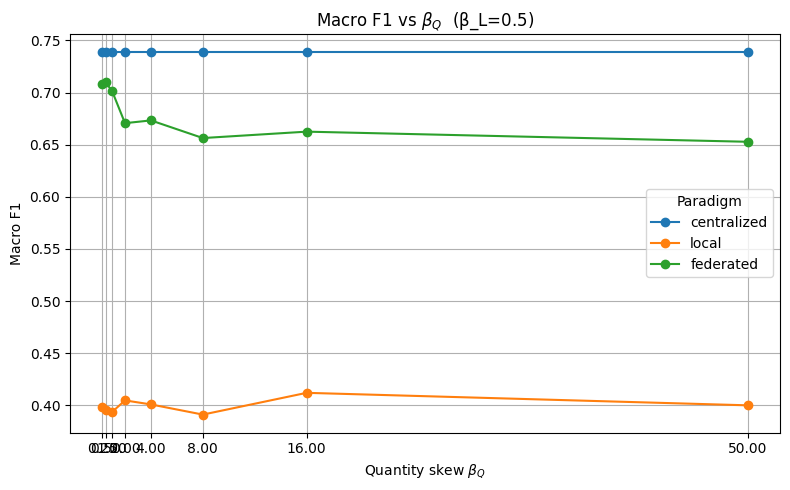

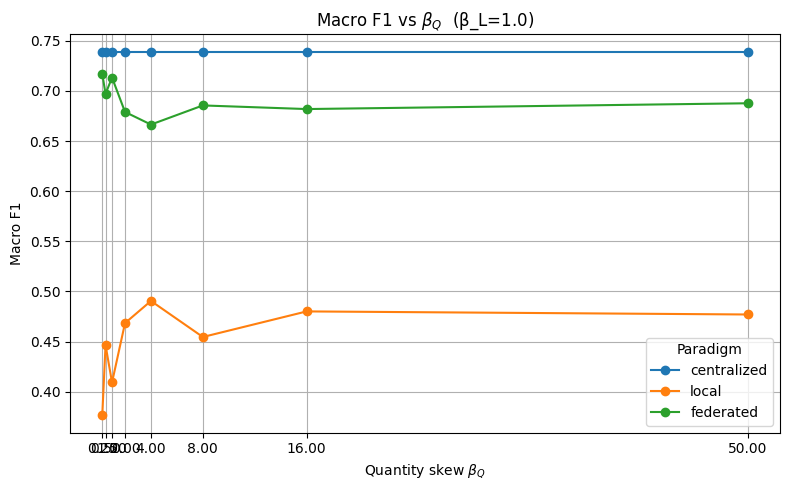

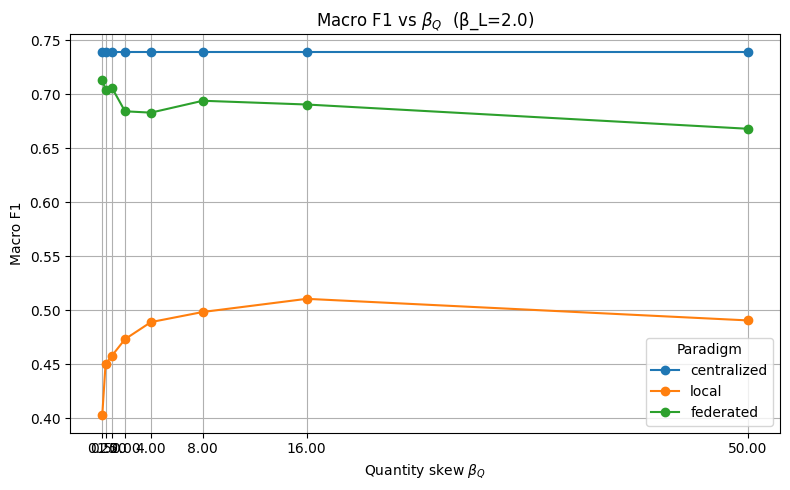

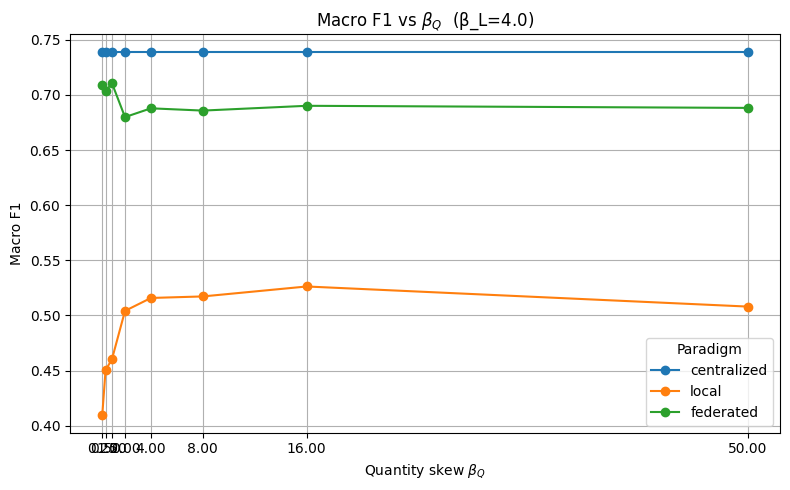

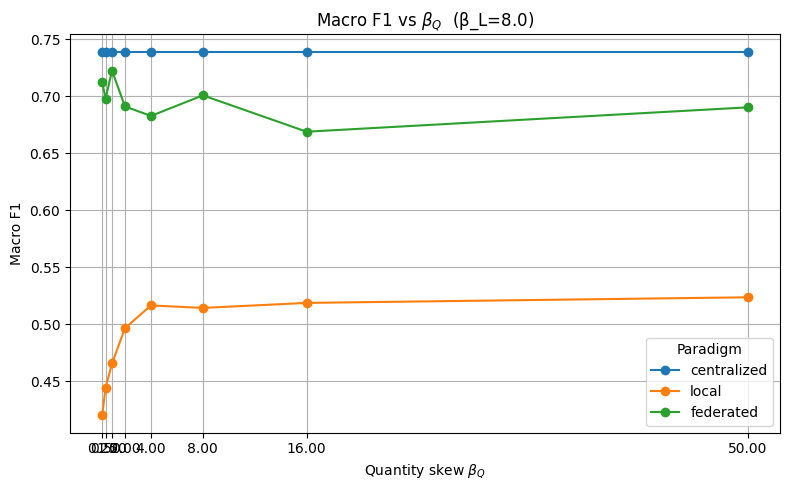

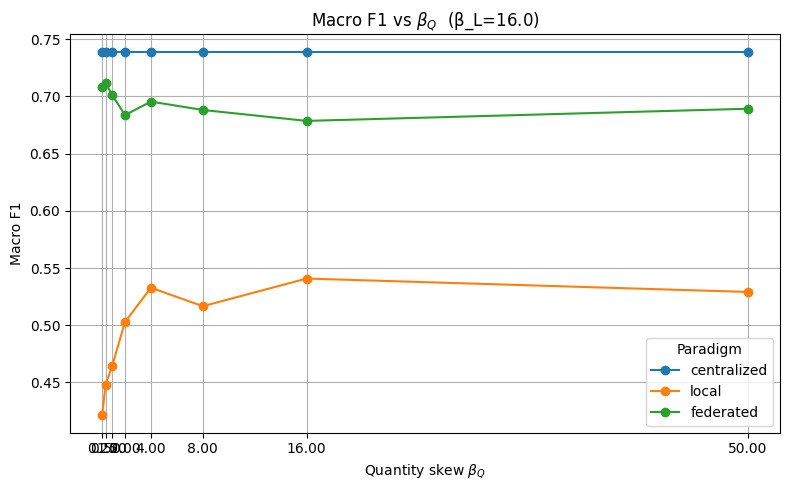

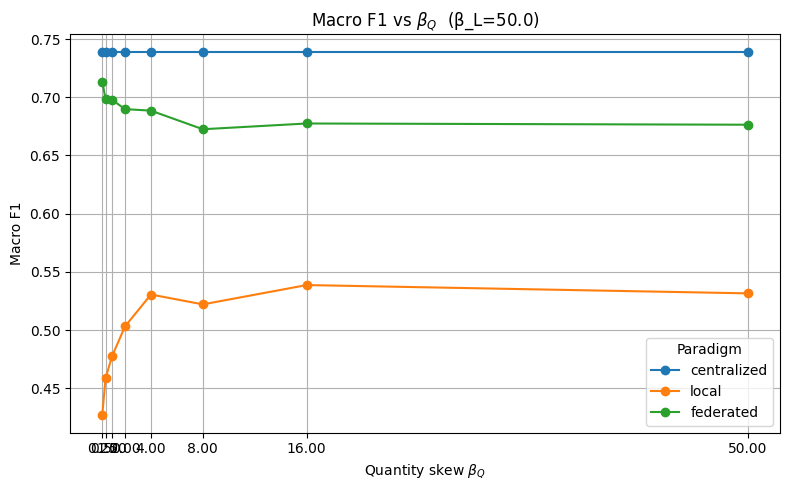

In [4]:
plot_quantity_skew_all_beta_L(csv_path)